In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


In [2]:

rolls = np.random.randint(1, 7, size=100_000)

p_even = (rolls % 2 == 0).mean()
p_gt4  = (rolls > 4).mean()
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [3]:

p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [4]:
flips = np.random.randint(0, 2, size=(100_000, 2))
heads = flips.sum(axis=1)

In [5]:

rolls = np.random.randint(1, 7, size=100_000)


even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.332  (true 1/3)


In [6]:

A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.498
P(A | B)  = 0.666
Independent? False


In [7]:
rolls = np.random.randint(1, 7, size=100_000)



In [8]:

p_disease   = 0.01
p_pos_given_D  = 0.99
p_pos_given_nD = 0.01

p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)


p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [9]:


N = 1_000_000
has_disease = np.random.rand(N) < p_disease

tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,
                     np.random.rand(N) < p_pos_given_nD)

among_positive = has_disease[tests_pos]
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.503


In [10]:

p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05


p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * (1 - p_spam))


p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print("P(free) =", p_free)
print("P(spam | free) =", p_spam_given_free)


P(free) = 0.16
P(spam | free) = 0.75


In [11]:

bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')


pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')

Bernoulli(0.3) mean ~ 0.288 (true 0.3)
Poisson(4) mean ~ 3.993 (true 4)


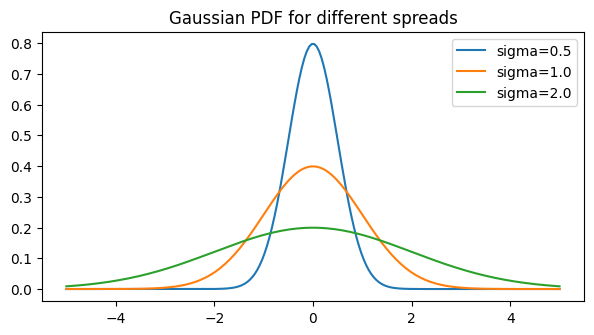

In [12]:


x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

Mean = 2.007


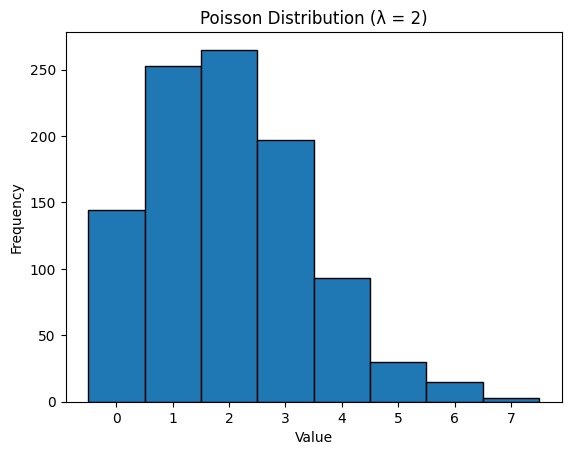

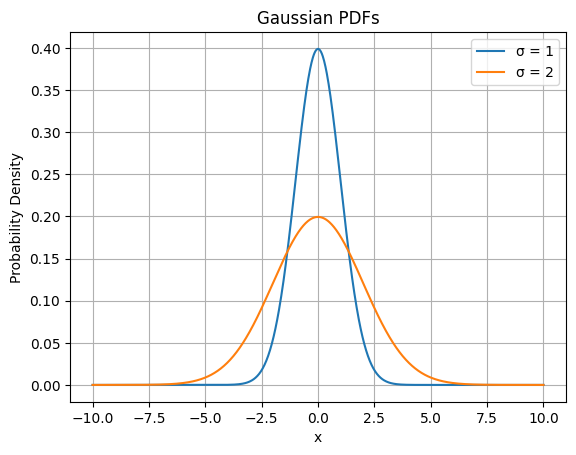

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Poisson(lambda=2) samples + mean
samples = np.random.poisson(lam=2, size=1000)
print("Mean =", np.mean(samples))

# 2. Histogram of the samples
plt.hist(
    samples,
    bins=np.arange(-0.5, samples.max() + 1.5, 1),
    edgecolor="black"
)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Poisson Distribution (λ = 2)")
plt.show()

# 3. Gaussian PDF for two sigmas on one plot
x = np.linspace(-10, 10, 1000)

mu = 0
sigma1 = 1
sigma2 = 2

pdf1 = (1 / (sigma1 * np.sqrt(2 * np.pi))) * \
       np.exp(-((x - mu) ** 2) / (2 * sigma1 ** 2))

pdf2 = (1 / (sigma2 * np.sqrt(2 * np.pi))) * \
       np.exp(-((x - mu) ** 2) / (2 * sigma2 ** 2))

plt.plot(x, pdf1, label="σ = 1")
plt.plot(x, pdf2, label="σ = 2")

plt.xlabel("x")
plt.ylabel("Probability Density")
plt.title("Gaussian PDFs")
plt.legend()
plt.grid()
plt.show()


In [16]:


from scipy.stats import entropy

fair   = [0.5, 0.5]
biased = [0.9, 0.1]
certain= [1.0, 0.0]


print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [17]:


P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])


print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')

D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [18]:


from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [20]:
import numpy as np


p4 = [1/4] * 4
p6 = [1/6] * 6

H4 = -sum(p * np.log2(p) for p in p4)
H6 = -sum(p * np.log2(p) for p in p6)

print("Entropy of 4-sided die =", H4)
print("Entropy of 6-sided die =", H6)



P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])

KL = np.sum(P * np.log2(P / Q))

print("KL Divergence D(P || Q) =", KL)



print("Most informative: Petal Length")
print("Least informative: Sepal Width")


Entropy of 4-sided die = 2.0
Entropy of 6-sided die = 2.584962500721156
KL Divergence D(P || Q) = 0.1187091007693073
Most informative: Petal Length
Least informative: Sepal Width
